In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4
from qick.asm_v2 import AveragerProgramV2

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.179"
ns_port = 8887
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8887
myqick PYRO:obj_cb5f2a66aa8e436180bb6b6132f29031@192.168.10.179:8080
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 16384 complex samples (2.381 us)
		32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 4096 complex samples (0.595 us)
		32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=

In [ ]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

config_all = ExperimentConfig(config_list)
config_all.update("res.res_gain_ge", 1)

arm_qubit = [
    "Q1",
    "Q2",
    "Q3",
    "Q4",
    "Q5",
    "Q6",
]
run_cfg = config_all.muxconfig(arm_qubit)


In [ ]:
run_cfg

{'name': ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6'],
 'res_ch': [0, 0, 0, 0, 0, 0],
 'qb_ch': [2, 7, 7, 7, 7, 7],
 'qb_ch_ef': [2],
 'ro_ch': [0, 0, 0, 0, 0, 0],
 'res_freq_ge': [5000, 5150, 5300, 5450, 5600, 5750],
 'res_length': 10,
 'res_gain_ge': [1, 1, 1, 1, 1, 1],
 'res_phase': [0, 0, 0, 0, 0, 0],
 'res_sigma': [0.005, 0.005, 0.005, 0.005, 0.005, 0.005],
 'ro_length': 5,
 'nqz_res': [2, 2, 2, 2, 2, 2],
 'chi': [False, False, False, False, False, False],
 'pulse_type': ['arb', 'arb', 'arb', 'arb', 'arb', 'arb'],
 'qb_freq_ge': [4497, 4000, 4000, 4000, 4000, 4000],
 'qb_mixer': [4497, 4000, 4000, 4000, 4000, 4000],
 'qb_gain_ge': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
 'qb_phase': [0, 0, 0, 0, 0, 0],
 'sigma_ge': [0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
 'pi_gain_ge': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
 'pi2_gain_ge': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
 'qb_flat_top_length_ge': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
 'qb_freq_ef': [4000],
 'qb_mixer_ef': [4000],
 'qb_gain_ef': [0.1],
 'qb_phase_ef': [0],
 'sig

In [ ]:
"""
BaseProgram: Base class for all QICK programs.
================================================
Centralizes generator declaration, readout, qubit pulse setup (prefix-aware),
standard gates, cooling, and measurement.
Subclasses only need to implement _initialize() and _body().
"""

from qick.asm_v2 import AveragerProgramV2


# ── Gate Name Mapping ──
# Maps shorthand gate names to pulse name templates.
# {pfx} is replaced by the transition prefix (e.g. "ge", "ef").
GATE_ALIAS = {
    # Clifford shorthand (used in AllXY / Tomography)
    "X": "x180_{pfx}",
    "Y": "y180_{pfx}",
    "X/2": "x90_{pfx}",
    "-X/2": "x90m_{pfx}",
    "Y/2": "y90_{pfx}",
    "-Y/2": "y90m_{pfx}",
    # Bare names without prefix
    "x180": "x180_{pfx}",
    "y180": "y180_{pfx}",
    "x90": "x90_{pfx}",
    "x90m": "x90m_{pfx}",
    "y90": "y90_{pfx}",
    "y90m": "y90m_{pfx}",
}


def resolve_gate(name, prefix="ge"):
    """Resolve shorthand gate name to actual pulse name.

    Examples:
        resolve_gate("X")      -> "x180_ge"
        resolve_gate("-X/2")   -> "x90m_ge"
        resolve_gate("x90")    -> "x90_ge"
        resolve_gate("x180_ge") -> "x180_ge"  (pass-through)
        resolve_gate("I")      -> "I"          (identity)
    """
    if name in ("I", "-I", None, "None"):
        return name
    if name in GATE_ALIAS:
        return GATE_ALIAS[name].format(pfx=prefix)
    return name  # already fully qualified


class BaseProgram(AveragerProgramV2):
    """
    Base class for all QICK programs.

    Key helpers:
    - declare_gen_auto()      : auto-handle mixer_freq for axis_sg_int4_v2
    - setup_resonator()       : readout channel + pulse config
    - setup_qubit_gen()       : qubit gen declaration (prefix-aware: ge/ef)
    - setup_qb_pulse()        : flexible pulse (const/arb/flat_top, gauss/cosine)
    - setup_standard_gates()  : 6 calibration gates for AllXY/RB/Tomography
    - apply_cool()            : cooling channel + pulse config
    - cooling_body()          : cooling pulse sequence for _body()
    - measure()               : readout pulse + trigger
    """

    # ── Generator helpers ──

    def declare_gen_auto(self, ch, nqz, mixer_key=None, cfg=None):
        """Declare generator, auto-handling mixer_freq for axis_sg_int4_v2."""
        if mixer_key and cfg and self.soccfg["gens"][ch]["type"] == "axis_sg_int4_v2":
            self.declare_gen(ch=ch, nqz=nqz, mixer_freq=cfg[mixer_key])
        else:
            self.declare_gen(ch=ch, nqz=nqz)

    def setup_qubit_gen(self, cfg, prefix="ge"):
        """
        Declare the qubit generator for a given prefix.
        ge -> cfg["qb_ch"] / nqz_qb / qb_mixer
        ef -> cfg["qb_ch_ef"] / nqz_qb_ef / qb_mixer_ef
        """
        if prefix == "ge":
            ch, nqz_key, mixer_key = cfg["qb_ch"], "nqz_qb", "qb_mixer"
        else:
            ch = cfg[f"qb_ch_{prefix}"]
            nqz_key = f"nqz_qb_{prefix}"
            mixer_key = f"qb_mixer_{prefix}"
        self.declare_gen_auto(ch, cfg[nqz_key], mixer_key, cfg)

    # ── Resonator setup ──

    def setup_resonator(self, cfg, prefix="ge"):
        """Configure resonator readout channel and flat_top pulse."""
        ro_ch = cfg["ro_ch"]
        res_ch = cfg["res_ch"]
        self.declare_gen(ch=res_ch, nqz=cfg["nqz_res"])
        self.declare_readout(ch=ro_ch, length=cfg["ro_length"])
        self.add_readoutconfig(
            ch=ro_ch, name="myro", freq=cfg[f"res_freq_{prefix}"], gen_ch=res_ch
        )
        self.add_gauss(
            ch=res_ch,
            name="readout",
            sigma=cfg["res_sigma"],
            length=5 * cfg["res_sigma"],
            even_length=True,
        )
        self.add_pulse(
            ch=res_ch,
            name="res_pulse",
            ro_ch=ro_ch,
            style="flat_top",
            envelope="readout",
            length=cfg["res_length"],
            freq=cfg[f"res_freq_{prefix}"],
            phase=cfg["res_phase"],
            gain=cfg[f"res_gain_{prefix}"],
        )

    # ── Mux pulse setup (flexible, prefix-aware) ──

    def set_mux(self, cfg, prefix="ge"):
        ro_chs = cfg["mux_ro_chs"]
        res_ch = cfg["mux_gen"]

        self.declare_gen(
            ch=res_ch,
            nqz=2,
            ro_ch=ro_chs[0],
            mixer_freq=cfg["mixer_freq"],
            mux_freqs=cfg[f"res_freq_{prefix}"],
            mux_gains=cfg[f"res_gain_{prefix}"],
            mux_phases=cfg["res_phase"],
        )
        for ch, f, ph in zip(
            cfg["mux_ro_chs"], cfg[f"res_freq_{prefix}"], cfg["mux_ro_phases"]
        ):
            self.declare_readout(
                ch=ch, length=cfg["ro_length"], freq=f, phase=ph, gen_ch=res_ch
            )

        self.add_pulse(
            ch=res_ch,
            name="readout",
            style="const",
            length=cfg["res_length"],
            mask=cfg["gen_mask"],
        )

    # ── Qubit pulse setup (flexible, prefix-aware) ──

    def setup_qb_pulse(
        self,
        cfg,
        prefix="ge",
        pulse_type=None,
        shape="gauss",
        name="qb_pulse",
        phase=None,
        gain_key=None,
        gain_override=None,
        ch=None,
        length_mult=5,
    ):
        """
        Configure a qubit pulse with automatic channel/gain/phase resolution.
        Envelopes are deduplicated: multiple pulses with same prefix+shape
        share one envelope.

        Args:
            cfg:          configuration dict
            prefix:       'ge' or 'ef' — selects channel, freq, sigma keys
            pulse_type:   'const', 'arb', or 'flat_top' (default: cfg["pulse_type"])
            shape:        envelope shape — 'gauss' or 'cosine'
            name:         pulse name
            phase:        phase in degrees (default: cfg["qb_phase"] / cfg["qb_phase_ef"])
            gain_key:     explicit cfg key for gain (default: f"qb_gain_{prefix}")
            gain_override: explicit gain value (overrides gain_key when not None)
            ch:           explicit channel override
            length_mult:  envelope length = sigma * length_mult (default 5)
        """
        # Resolve channel
        if ch is None:
            ch = cfg["qb_ch"] if prefix == "ge" else cfg[f"qb_ch_{prefix}"]

        # Resolve pulse type from config if not specified
        if pulse_type is None:
            pulse_type = cfg.get("pulse_type", "arb")

        # Resolve phase from config if not specified
        if phase is None:
            if prefix == "ge":
                phase = cfg.get("qb_phase", 0)
            else:
                phase = cfg.get(f"qb_phase_{prefix}", 0)

        # Resolve gain: gain_override takes precedence over gain_key
        if gain_override is not None:
            gain = gain_override
        elif gain_key:
            gain = cfg[gain_key]
        else:
            gain = cfg.get(f"qb_gain_{prefix}", 0)

        # Resolve frequency
        freq = cfg[f"qb_freq_{prefix}"]

        # Add envelope if needed (deduplicated per channel+prefix+shape)
        env_name = None
        if pulse_type in ("arb", "flat_top"):
            env_name = f"env_{prefix}_{shape}"
            if not hasattr(self, "_added_envs"):
                self._added_envs = set()
            env_key = (ch, env_name)
            if env_key not in self._added_envs:
                sigma = cfg[f"sigma_{prefix}"]
                if shape in ("gauss", "gaussian"):
                    self.add_gauss(
                        ch=ch,
                        name=env_name,
                        sigma=sigma,
                        length=sigma * length_mult,
                        even_length=True,
                    )
                elif shape in ("cos", "cosine"):
                    self.add_cosine(
                        ch=ch,
                        name=env_name,
                        length=sigma * length_mult,
                        even_length=True,
                    )
                else:
                    raise ValueError(f"Unknown pulse shape: {shape}")
                self._added_envs.add(env_key)

        # Add pulse
        if pulse_type == "const":
            self.add_pulse(
                ch=ch,
                name=name,
                style="const",
                length=cfg[f"qb_length_{prefix}"],
                freq=freq,
                phase=phase,
                gain=gain,
            )
        elif pulse_type == "arb":
            self.add_pulse(
                ch=ch,
                name=name,
                style="arb",
                envelope=env_name,
                freq=freq,
                phase=phase,
                gain=gain,
            )
        elif pulse_type == "flat_top":
            self.add_pulse(
                ch=ch,
                name=name,
                style="flat_top",
                envelope=env_name,
                freq=freq,
                phase=phase,
                gain=gain,
                length=cfg[f"qb_flat_top_length_{prefix}"],
            )

    def setup_standard_gates(self, cfg, prefix="ge", pulse_type=None, shape="gauss"):
        """
        Setup 6 standard calibration gates for AllXY, RB, State Tomography:
        X180, Y180, X90, X90m, Y90, Y90m.
        """
        gates = [
            (f"x180_{prefix}", 0, f"pi_gain_{prefix}"),
            (f"y180_{prefix}", 90, f"pi_gain_{prefix}"),
            (f"x90_{prefix}", 0, f"pi2_gain_{prefix}"),
            (f"x90m_{prefix}", 180, f"pi2_gain_{prefix}"),
            (f"y90_{prefix}", 90, f"pi2_gain_{prefix}"),
            (f"y90m_{prefix}", -90, f"pi2_gain_{prefix}"),
        ]
        for gate_name, gate_phase, gain_key in gates:
            self.setup_qb_pulse(
                cfg,
                prefix=prefix,
                pulse_type=pulse_type,
                shape=shape,
                name=gate_name,
                phase=gate_phase,
                gain_key=gain_key,
            )

    # ── Cooling ──

    def apply_cool(self, cfg, style="flat_top"):
        """
        Configure cooling channels and pulses.
        style: "flat_top" (most experiments) or "const" (legacy).
        """
        for i in [1, 2]:
            ch_key = f"cool_ch{i}"
            if ch_key not in cfg:
                continue
            ch = cfg[ch_key]
            nqz = cfg.get(f"nqz_cool_ch{i}", 2)
            mixer_key = f"cool_mixer{i}"
            self.declare_gen_auto(ch, nqz, mixer_key, cfg)

            if style == "flat_top":
                env_name = f"cooling{i}"
                self.add_gauss(
                    ch=ch,
                    name=env_name,
                    sigma=cfg["res_sigma"],
                    length=cfg["res_sigma"] * 5,
                    even_length=True,
                )
                self.add_pulse(
                    ch=ch,
                    name=f"cool_pulse{i}",
                    envelope=env_name,
                    style="flat_top",
                    length=cfg["cool_length"],
                    freq=cfg[f"cool_freq_{i}"],
                    phase=0,
                    gain=cfg[f"cool_gain_{i}"],
                )
            else:  # const
                self.add_pulse(
                    ch=ch,
                    name=f"cool_pulse{i}",
                    style="const",
                    length=cfg["cool_length"],
                    freq=cfg[f"cool_freq_{i}"],
                    phase=0,
                    gain=cfg[f"cool_gain_{i}"],
                )

    def cooling_body(self, cfg, ring_down=0.5):
        """Execute cooling pulse sequence inside _body(). Returns True if cooling ran."""
        if not cfg.get("cooling", False):
            return False
        self.pulse(ch=cfg["cool_ch1"], name="cool_pulse1", t=0)
        self.pulse(ch=cfg["cool_ch2"], name="cool_pulse2", t=0)
        self.delay_auto(ring_down, tag="Ring down")
        return True

    # ── Measurement ──

    def measure(self, cfg):
        """Execute standard readout pulse + trigger."""
        self.pulse(ch=cfg["res_ch"], name="res_pulse", t=0)
        self.trigger(ros=[cfg["ro_ch"]], pins=[0], t=cfg["trig_time"])

    def measure_mux(self, cfg):
        """Execute MUX readout pulse + trigger."""
        self.pulse(ch=cfg["mux_gen"], name="readout", t=0)
        self.trigger(ros=cfg["mux_ro_chs"], pins=[0], t=0, ddr4=False)

# Config

In [ ]:
class MixMuxGenMuxROProgram(BaseProgram):
    def _initialize(self, cfg):
        self.set_mux(cfg)

    def _body(self, cfg):
        self.measure_mux(cfg)


run_cfg.update({"res_length": 0.3, "ro_length": 1.5})


prog = MixMuxGenMuxROProgram(soccfg, reps=1, final_delay=0.2, cfg=run_cfg)
iq_list = prog.acquire_decimated(soc, rounds=10)
t = prog.get_time_axis(ro_index=0)


  0%|          | 0/10 [00:00<?, ?it/s]

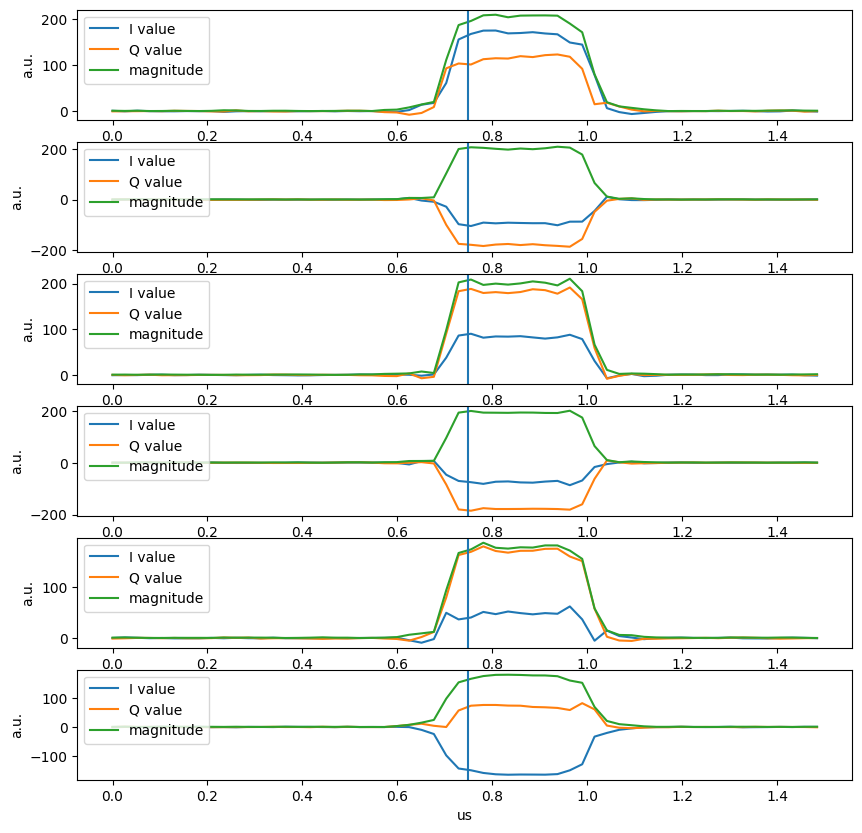

In [ ]:
fig, axes = plt.subplots(len(run_cfg["mux_ro_chs"]), 1, figsize=(10, 10))
for i, ch in enumerate(run_cfg["mux_ro_chs"]):
    plot = axes[i]
    plot.plot(t, iq_list[i][:, 0], label="I value")
    plot.plot(t, iq_list[i][:, 1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1, 1j])), label="magnitude")
    plot.axvline(0.75)
    plot.legend(loc="upper left")
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us")


# Onetone

In [ ]:
from tqdm.auto import tqdm
import qick_workspace.tools.fitting as fitter

In [ ]:
class MuxOneTone(BaseProgram):
    def _initialize(self, cfg):
        self.set_mux(cfg)

    def _body(self, cfg):
        self.measure_mux(cfg)

In [ ]:
n_roch = len(arm_qubit)
F_Span = 10
F_Steps = 41
sweep = np.linspace(-F_Span, F_Span, F_Steps)
z_list = [[] for _ in range(n_roch)]

run_cfg = config_all.muxconfig(arm_qubit)
r = run_cfg["res_freq_ge"]

for i in tqdm(sweep):
    run_cfg["res_freq_ge"] = np.array(r) + i

    prog = MuxOneTone(soccfg, reps=100, final_delay=0.5, cfg=run_cfg)
    results = prog.acquire(soc, rounds=1, progress=False)
    for idx, res in enumerate(results):
        z_list[idx].append(res[0][0] + 1j * res[0][1])

  0%|          | 0/41 [00:00<?, ?it/s]

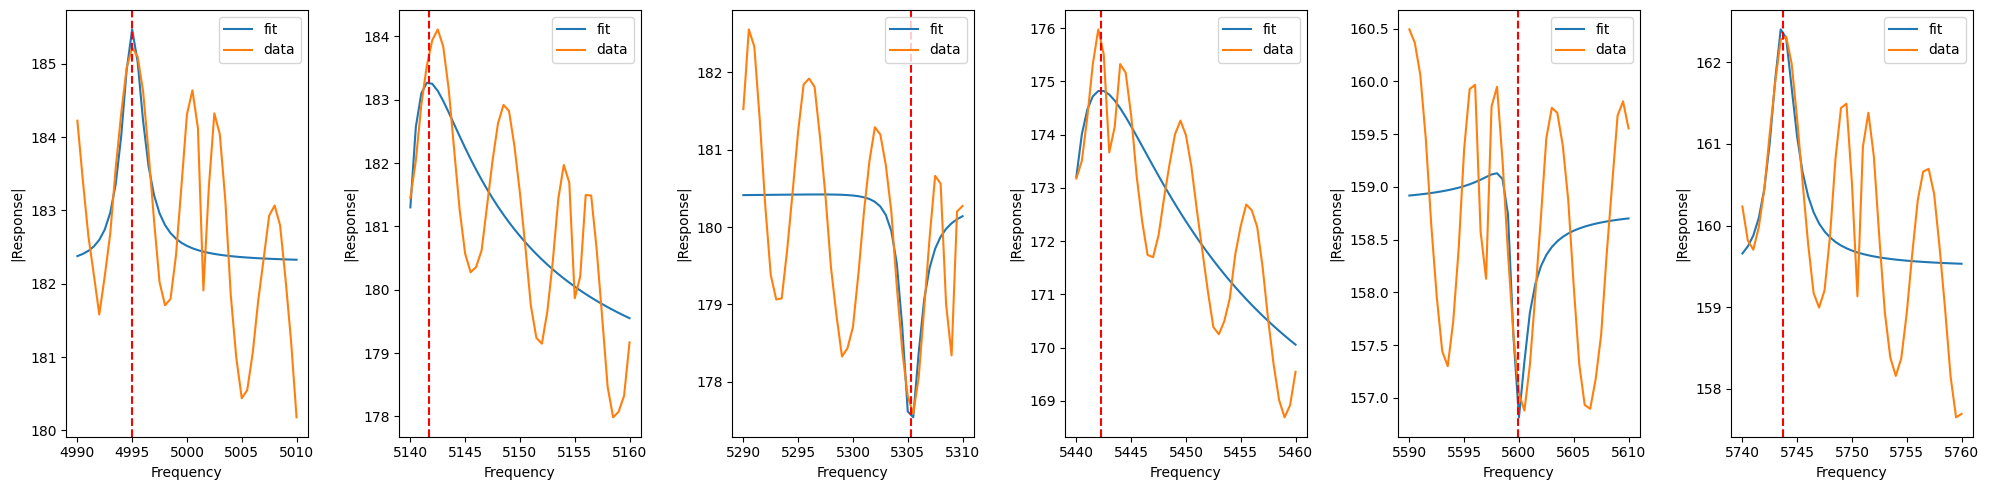

In [ ]:
popt = [[] for _ in range(n_roch)]
fit_res = [[]] * n_roch


fig, ax = plt.subplots(1, n_roch, figsize=(20, 5))

for i in range(n_roch):
    freq_sweep = r[i] + sweep

    mag_response = np.abs(z_list[i])
    popt[i], _ = fitter.fit_asym_lor(freq_sweep, mag_response)
    ax[i].plot(freq_sweep, fitter.asym_lorfunc(freq_sweep, *popt[i]), label="fit")
    ax[i].plot(freq_sweep, mag_response, label="data")
    ax[i].legend(loc="upper right")
    ax[i].set_xlabel("Frequency")
    ax[i].set_ylabel("|Response|")
    ax[i].axvline(popt[i][2], color="red", linestyle="--")


plt.tight_layout()
plt.show()